# Feature Selection – House Price Prediction


In [1]:
import time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV, Ridge
from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
DATA_PATH = "../Data/train.csv"   # dataset House Prices (Kaggle)
TARGET = "SalePrice"
K_LIST = [10, 20, 30]     # số feature giữ lại

## 1. Tiền xử lý và hàm evaluate


In [2]:

df = pd.read_csv(DATA_PATH)
df = df.drop(columns=["Id"], errors="ignore").drop_duplicates()
# outlier kinh điển của bộ dữ liệu
if {"GrLivArea", TARGET}.issubset(df.columns):
    df = df[~((df["GrLivArea"] > 4000) & (df[TARGET] < 300000))]
# bỏ cột thiếu > 50%
miss = df.isna().mean()
df = df.drop(columns=miss[miss > 0.5].index)
# điền thiếu
for c in df.columns:
    if c == TARGET:
        continue
    if df[c].dtype == "object":
        df[c] = df[c].fillna(df[c].mode()[0])
    else:
        df[c] = df[c].fillna(df[c].median())

X = pd.get_dummies(df.drop(columns=[TARGET]), drop_first=True).astype(float)
y = np.log1p(df[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler().fit(X_train)
X_train = pd.DataFrame(scaler.transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

def evaluate(model, features):
    m = clone(model)
    t0 = time.time()
    m.fit(X_train[features], y_train)
    pred = m.predict(X_test[features])
    elapsed = time.time() - t0
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    return r2, rmse, mae, elapsed


print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (1166, 232) | Test: (292, 232)


## 2. Ba mô hình cơ bản

In [3]:
models = {
    "SVR": SVR(kernel="rbf", C=10, epsilon=0.05),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                            subsample=0.8, colsample_bytree=0.8,
                            random_state=RANDOM_STATE, n_jobs=-1),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
}

## 3. Các phương pháp chọn feature
**Wrapper**
- **RFE** với 3 estimator: SVR (linear), RandomForest, XGBoost
- **Sequential Feature Selection** (forward): dùng Ridge làm estimator để chạy trong thời gian hợp lý (với 200+ feature, dùng SVR/RF sẽ rất lâu)

**Embedded**
- **Lasso** (LassoCV): lấy top-K theo |hệ số| và tập các hệ số khác 0
- **Feature importance** của RandomForest và XGBoost: lấy top-K

In [4]:
cols = X_train.columns

def select_rfe(est, k):
    r = RFE(est, n_features_to_select=k, step=0.2).fit(X_train, y_train)
    return list(cols[r.support_])

def select_sfs(k):
    s = SequentialFeatureSelector(Ridge(alpha=1.0), n_features_to_select=k,
                                  direction="forward", cv=3, scoring="r2", n_jobs=-1)
    s.fit(X_train, y_train)
    return list(cols[s.get_support()])

lasso = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=20000).fit(X_train, y_train)
lasso_coef = pd.Series(np.abs(lasso.coef_), index=cols).sort_values(ascending=False)
print(f"Lasso alpha={lasso.alpha_:.5f}, số hệ số khác 0: {(lasso_coef > 0).sum()}")

def select_lasso_topk(k):
    nz = lasso_coef[lasso_coef > 0]
    return list(nz.head(k).index)

def select_importance(est, k):
    m = clone(est).fit(X_train, y_train)
    imp = pd.Series(m.feature_importances_, index=cols).sort_values(ascending=False)
    return list(imp.head(k).index)

Lasso alpha=0.00323, số hệ số khác 0: 97


## 4. Chạy chọn feature

In [5]:
feature_sets = {}   # (method, k) -> list feature
select_time = {}

def run(method, k, fn):
    t0 = time.time()
    feats = fn()
    select_time[(method, k)] = time.time() - t0
    feature_sets[(method, k)] = feats
    print(f"{method:<22} k={k:<3} -> {len(feats):>3} features  ({select_time[(method, k)]:.1f}s)")

for k in K_LIST:
    run("RFE-SVR", k, lambda: select_rfe(SVR(kernel="linear", C=1), k))
    run("RFE-RandomForest", k, lambda: select_rfe(models["RandomForest"], k))
    run("RFE-XGBoost", k, lambda: select_rfe(models["XGBoost"], k))
    run("SFS-Forward(Ridge)", k, lambda: select_sfs(k))
    run("Lasso-TopK", k, lambda: select_lasso_topk(k))
    run("Importance-RF", k, lambda: select_importance(models["RandomForest"], k))
    run("Importance-XGB", k, lambda: select_importance(models["XGBoost"], k))

# Lasso: tập hệ số khác 0 
nz = list(lasso_coef[lasso_coef > 0].index)
feature_sets[("Lasso-NonZero", len(nz))] = nz
select_time[("Lasso-NonZero", len(nz))] = 0.0

# Baseline tham khảo 
feature_sets[("Baseline-All", len(cols))] = list(cols)
select_time[("Baseline-All", len(cols))] = 0.0

RFE-SVR                k=10  ->  10 features  (15.9s)
RFE-RandomForest       k=10  ->  10 features  (2.2s)
RFE-XGBoost            k=10  ->  10 features  (0.9s)
SFS-Forward(Ridge)     k=10  ->  10 features  (38.5s)
Lasso-TopK             k=10  ->  10 features  (0.0s)
Importance-RF          k=10  ->  10 features  (0.4s)
Importance-XGB         k=10  ->  10 features  (0.3s)
RFE-SVR                k=20  ->  20 features  (15.9s)
RFE-RandomForest       k=20  ->  20 features  (2.1s)
RFE-XGBoost            k=20  ->  20 features  (1.1s)
SFS-Forward(Ridge)     k=20  ->  20 features  (54.1s)
Lasso-TopK             k=20  ->  20 features  (0.0s)
Importance-RF          k=20  ->  20 features  (0.4s)
Importance-XGB         k=20  ->  20 features  (0.3s)
RFE-SVR                k=30  ->  30 features  (16.3s)
RFE-RandomForest       k=30  ->  30 features  (2.3s)
RFE-XGBoost            k=30  ->  30 features  (1.0s)
SFS-Forward(Ridge)     k=30  ->  30 features  (79.2s)
Lasso-TopK             k=30  ->  30 feat

## 5. Chạy 3 mô hình trên từng tập feature

In [6]:
rows = []
for (method, k), feats in feature_sets.items():
    for name, model in models.items():
        r2, rmse, mae, t = evaluate(model, feats)
        rows.append(dict(method=method, k=k, n_features=len(feats), model=name,
                         R2=r2, RMSE=rmse, MAE=mae, train_time=t,
                         select_time=select_time[(method, k)]))
    print("done:", method, k)

results = pd.DataFrame(rows)
results.to_csv("results_nhu.csv", index=False)
with open("selected_features_nhu.json", "w", encoding="utf-8") as f:
    json.dump({f"{m}|{k}": v for (m, k), v in feature_sets.items()}, f, ensure_ascii=False, indent=1)
results.sort_values("R2", ascending=False).head(15)

done: RFE-SVR 10
done: RFE-RandomForest 10
done: RFE-XGBoost 10
done: SFS-Forward(Ridge) 10
done: Lasso-TopK 10
done: Importance-RF 10
done: Importance-XGB 10
done: RFE-SVR 20
done: RFE-RandomForest 20
done: RFE-XGBoost 20
done: SFS-Forward(Ridge) 20
done: Lasso-TopK 20
done: Importance-RF 20
done: Importance-XGB 20
done: RFE-SVR 30
done: RFE-RandomForest 30
done: RFE-XGBoost 30
done: SFS-Forward(Ridge) 30
done: Lasso-TopK 30
done: Importance-RF 30
done: Importance-XGB 30
done: Lasso-NonZero 97
done: Baseline-All 232


,method,k,n_features,model,R2,RMSE,MAE,train_time,select_time
55,Lasso-TopK,30,30,XGBoost,0.915536,0.119326,0.083174,0.223664,0.000231
52,SFS-Forward(Ridge),30,30,XGBoost,0.910013,0.123165,0.082568,0.112113,79.172229
31,SFS-Forward(Ridge),20,20,XGBoost,0.907487,0.124882,0.085091,0.106191,54.080070
67,Baseline-All,232,232,XGBoost,0.907407,0.124936,0.085127,0.326963,0.000000
43,RFE-SVR,30,30,XGBoost,0.905605,0.126145,0.086504,0.099674,16.329824
64,Lasso-NonZero,97,97,XGBoost,0.904872,0.126634,0.086448,0.181286,0.000000
34,Lasso-TopK,20,20,XGBoost,0.903350,0.127644,0.087901,0.101352,0.000257
49,RFE-XGBoost,30,30,XGBoost,0.899176,0.130371,0.090275,0.104029,0.964566
28,RFE-XGBoost,20,20,XGBoost,0.898900,0.130549,0.090538,0.098125,1.101515
10,SFS-Forward(Ridge),10,10,XGBoost,0.898614,0.130734,0.086429,0.081896,38.490608


## 6. Kết quả

In [7]:
pivot_r2 = results.pivot_table(index=["method", "k"], columns="model", values="R2").round(4)
pivot_r2

model                   RandomForest     SVR  XGBoost
method             k                                 
Baseline-All       232        0.8737  0.7509   0.9074
Importance-RF      10         0.8513  0.8206   0.8664
                   20         0.8666  0.8765   0.8964
                   30         0.8692  0.8501   0.8963
Importance-XGB     10         0.8329  0.8189   0.8419
                   20         0.8632  0.8496   0.8820
                   30         0.8713  0.8734   0.8954
Lasso-NonZero      97         0.8747  0.8169   0.9049
Lasso-TopK         10         0.8601  0.8650   0.8896
                   20         0.8726  0.8735   0.9033
                   30         0.8733  0.8645   0.9155
RFE-RandomForest   10         0.8505  0.8206   0.8658
                   20         0.8672  0.8765   0.8929
                   30         0.8699  0.8485   0.8909
RFE-SVR            10         0.8599  0.8481   0.8815
                   20         0.8687  0.8333   0.8961
                   30         0.8721  0.8805   0.9056
RFE-XGBoost        10         0.8334  0.8189   0.8424
                   20         0.8723  0.8648   0.8989
                   30         0.8705  0.8822   0.8992
SFS-Forward(Ridge) 10         0.8737  0.8908   0.8986
                   20         0.8810  0.8432   0.9075
                   30         0.8844  0.8633   0.9100

In [8]:
pivot_rmse = results.pivot_table(index=["method", "k"], columns="model", values="RMSE").round(4)
pivot_time = results.pivot_table(index=["method", "k"], columns="model", values="train_time").round(3)
display(pivot_rmse); display(pivot_time)

model                   RandomForest     SVR  XGBoost
method             k                                 
Baseline-All       232        0.1459  0.2049   0.1249
Importance-RF      10         0.1583  0.1739   0.1501
                   20         0.1499  0.1443   0.1322
                   30         0.1485  0.1589   0.1322
Importance-XGB     10         0.1678  0.1747   0.1633
                   20         0.1519  0.1592   0.1410
                   30         0.1473  0.1461   0.1328
Lasso-NonZero      97         0.1453  0.1757   0.1266
Lasso-TopK         10         0.1536  0.1509   0.1364
                   20         0.1465  0.1460   0.1276
                   30         0.1461  0.1511   0.1193
RFE-RandomForest   10         0.1588  0.1739   0.1504
                   20         0.1496  0.1443   0.1344
                   30         0.1481  0.1598   0.1356
RFE-SVR            10         0.1537  0.1600   0.1413
                   20         0.1488  0.1676   0.1324
                   30         0.1468  0.1419   0.1261
RFE-XGBoost        10         0.1676  0.1747   0.1630
                   20         0.1467  0.1509   0.1305
                   30         0.1477  0.1409   0.1304
SFS-Forward(Ridge) 10         0.1459  0.1357   0.1307
                   20         0.1416  0.1626   0.1249
                   30         0.1396  0.1518   0.1232

model                   RandomForest    SVR  XGBoost
method             k                                
Baseline-All       232         0.425  0.074    0.327
Importance-RF      10          0.248  0.111    0.083
                   20          0.274  0.092    0.108
                   30          0.288  0.058    0.120
Importance-XGB     10          0.243  0.083    0.095
                   20          0.249  0.096    0.099
                   30          0.259  0.074    0.116
Lasso-NonZero      97          0.311  0.053    0.181
Lasso-TopK         10          0.252  0.117    0.093
                   20          0.260  0.093    0.101
                   30          0.246  0.071    0.224
RFE-RandomForest   10          0.259  0.112    0.097
                   20          0.272  0.091    0.113
                   30          0.284  0.063    0.117
RFE-SVR            10          0.235  0.133    0.087
                   20          0.257  0.092    0.105
                   30          0.263  0.077    0.100
RFE-XGBoost        10          0.250  0.082    0.075
                   20          0.258  0.088    0.098
                   30          0.270  0.074    0.104
SFS-Forward(Ridge) 10          0.234  0.106    0.082
                   20          0.256  0.088    0.106
                   30          0.249  0.076    0.112

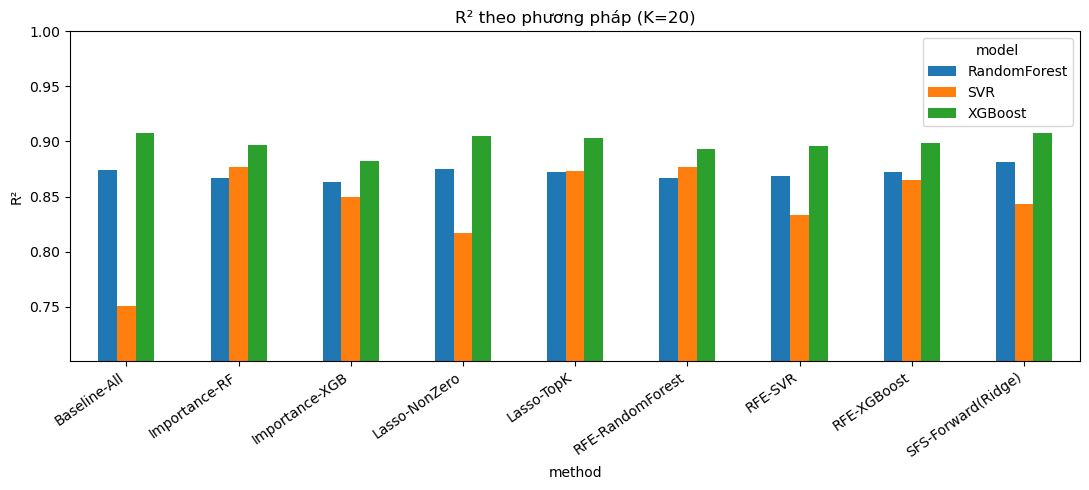

In [9]:
# R2 theo phương pháp tại từng K (cột = mô hình)
k_plot = 20 if 20 in K_LIST else K_LIST[0]
sub = results[(results.k == k_plot) | results.method.isin(["Lasso-NonZero", "Baseline-All"])]
p = sub.pivot_table(index="method", columns="model", values="R2")
p.plot(kind="bar", figsize=(11, 5))
plt.title(f"R² theo phương pháp (K={k_plot})"); plt.ylabel("R²")
plt.ylim(max(0, p.min().min() - 0.05), 1); plt.xticks(rotation=35, ha="right")
plt.tight_layout(); plt.show()

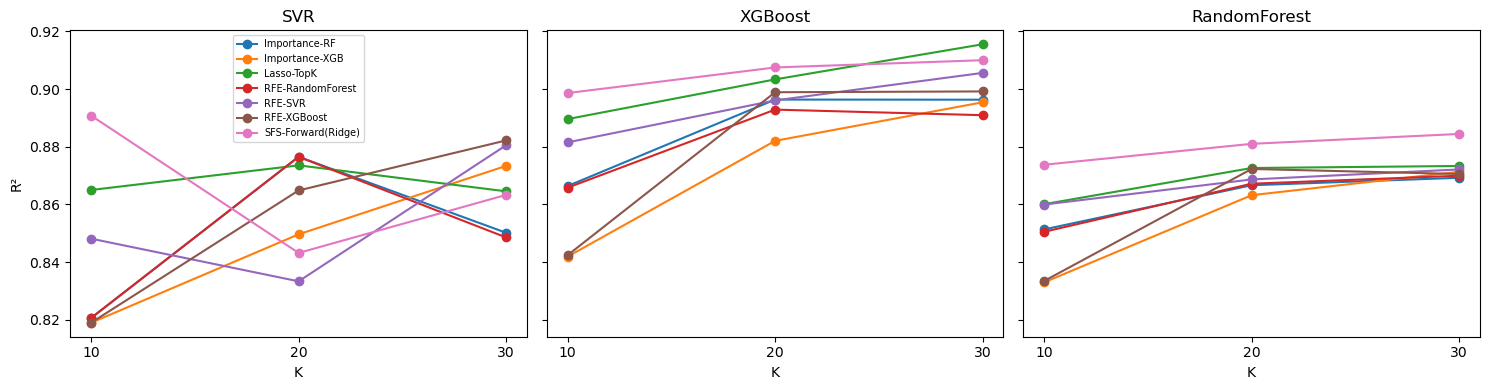

In [10]:
# R2 theo K cho từng phương pháp
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, name in zip(axes, models):
    d = results[(results.model == name) & results.method.isin(
        [m for m in results.method.unique() if m not in ("Lasso-NonZero", "Baseline-All")])]
    for m, g in d.groupby("method"):
        ax.plot(g.k, g.R2, marker="o", label=m)
    ax.set_title(name); ax.set_xlabel("K"); ax.set_xticks(K_LIST)
axes[0].set_ylabel("R²"); axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

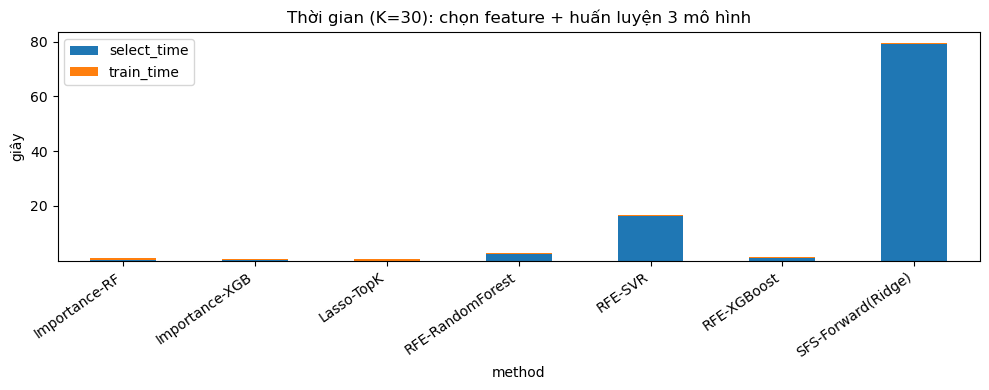

In [11]:
# Thời gian: chọn feature + huấn luyện (K lớn nhất)
kmax = max(K_LIST)
t = results[results.k == kmax].groupby("method")[["select_time", "train_time"]].agg(
    {"select_time": "first", "train_time": "sum"})
t.plot(kind="bar", stacked=True, figsize=(10, 4))
plt.title(f"Thời gian (K={kmax}): chọn feature + huấn luyện 3 mô hình"); plt.ylabel("giây")
plt.xticks(rotation=35, ha="right"); plt.tight_layout(); plt.show()

In [12]:
# Feature được nhiều phương pháp chọn nhất (K = k_plot)
from collections import Counter
cnt = Counter()
for (m, k), feats in feature_sets.items():
    if k == k_plot and m != "Baseline-All":
        cnt.update(feats)
pd.DataFrame(cnt.most_common(15), columns=["feature", "số phương pháp chọn"])

,feature,số phương pháp chọn
0,OverallQual,7
1,YearBuilt,7
2,BsmtFinSF1,7
3,TotalBsmtSF,7
4,GrLivArea,7
5,Fireplaces,7
6,GarageCars,7
7,OverallCond,6
8,GarageArea,6
9,YearRemodAdd,5


### Nhận xét và kết luận

**1. Kết quả tốt nhất**

| Mô hình | Cấu hình tốt nhất | R² | Baseline (232 feature) | Chênh lệch |
|---|---|---|---|---|
| SVR | SFS, K=10 | 0.8908 | 0.7509 | +0.1399 |
| XGBoost | Lasso-TopK, K=30 | **0.9155** | 0.9074 | +0.0081 |
| RandomForest | SFS, K=30 | 0.8844 | 0.8737 | +0.0107 |

- Cấu hình tốt nhất toàn bộ là **Lasso top-30 + XGBoost**: R² = 0.9155, RMSE = 0.1193 (baseline 0.1249), MAE = 0.0832. Mô hình chỉ dùng 30 trong 232 feature mà vẫn tốt hơn baseline.
- Xét R² trung bình của 3 mô hình: SFS (0.8836) > Lasso-TopK (0.8797) > RFE-SVR (0.8718) > Importance-RF (0.8659) ≈ RFE-RF (0.8648) ≈ RFE-XGB (0.8647) > Importance-XGB (0.8587).

**2. Wrapper và Embedded**
- Độ chính xác tương đương: Wrapper trung bình 0.8712, Embedded 0.8681 (chênh ~0.003).
- Chi phí khác nhau rất lớn: thời gian chọn feature trung bình của Wrapper ~20 giây, Embedded ~0.25 giây.
- SFS tốt nhất về R² nhưng chậm nhất (trung bình 58 giây, K=30 mất ~80 giây). Lasso-TopK gần như không tốn thời gian mà R² chỉ thấp hơn SFS ~0.004, nên **Lasso-TopK là lựa chọn cân bằng nhất** (chưa tính thời gian huấn luyện `LassoCV` ban đầu).
- Lasso-NonZero giữ 97 feature nhưng không tốt hơn top-30 (XGBoost 0.9049, RandomForest 0.8747, SVR 0.8169), cho thấy giữ nhiều feature hơn không giúp ích.

**3. Ảnh hưởng của K**
- R² trung bình tăng theo K: K=10 là 0.8539, K=20 là 0.8755, K=30 là 0.8803. Mức tăng từ 20 lên 30 chỉ ~0.005, hiệu quả giảm dần.
- Ngoại lệ là SVR: SFS ở K=10 cho kết quả tốt nhất (0.8908), cao hơn K=20 và K=30, nghĩa là với SVR ít feature nhưng chọn đúng hiệu quả hơn nhiều feature.
- Với XGBoost và RandomForest, chỉ 3/21 cấu hình đạt hoặc vượt baseline. Muốn không tụt hiệu năng cần K ≥ 20 và dùng phương pháp tốt (SFS, Lasso).

**4. Mô hình nhạy với feature selection**
- **SVR hưởng lợi nhiều nhất:** baseline chỉ 0.7509, nhưng cả 21 cấu hình chọn feature đều vượt baseline, trung bình +0.10 R². Nguyên nhân có thể là kernel RBF dựa trên khoảng cách trên mọi feature nên bị ảnh hưởng bởi nhiễu và các cột one-hot ít liên quan khi có 232 chiều.
- **XGBoost và RandomForest ít nhạy hơn:** hai mô hình cây đã tự chọn feature khi huấn luyện, baseline đã cao (0.9074 và 0.8737), feature selection chỉ giúp thêm khoảng 0.01.
- **Thời gian huấn luyện:** XGBoost giảm từ 0.33 giây xuống ~0.11 giây, RandomForest từ 0.41 giây xuống ~0.25 giây; SVR không đổi đáng kể vì dữ liệu nhỏ.

**5. Feature quan trọng**
- **7 feature được cả 7 phương pháp cùng chọn (K=20):** `OverallQual`, `YearBuilt`, `BsmtFinSF1`, `TotalBsmtSF`, `GrLivArea`, `Fireplaces`, `GarageCars`. Đây là nhóm feature ổn định nhất, không phụ thuộc kiểu chọn (Wrapper hay Embedded).
- **6/7 phương pháp chọn:** `OverallCond`, `GarageArea`. **5/7:** `YearRemodAdd`, `CentralAir_Y`. **4/7:** `MSZoning_RL`, `MSZoning_RM`, `LotArea`, `1stFlrSF`.
- Các feature thuộc bốn nhóm chính: chất lượng và tình trạng nhà (`OverallQual`, `OverallCond`); diện tích (`GrLivArea`, `TotalBsmtSF`, `BsmtFinSF1`, `1stFlrSF`, `LotArea`); tuổi nhà (`YearBuilt`, `YearRemodAdd`); tiện nghi (`GarageCars`, `GarageArea`, `Fireplaces`, `CentralAir_Y`). Kết quả khớp trực giác: giá nhà phụ thuộc mạnh vào chất lượng, diện tích và năm xây.
- Một số cặp feature tương quan cao (như `GarageCars` và `GarageArea`, `TotalBsmtSF` và `1stFlrSF`) cùng được chọn. Điều này ít ảnh hưởng đến mô hình cây nhưng có thể là một lý do khiến SVR cần chọn lọc feature kỹ hơn.



